# **Фильтры, частотные характеристики и ПИД регулятор**
## **Цели на сегодня**

---

Во время этого практического занятия мы:
* Поймeм разницу между статическими и динамическими системами
* Изучим фильтры нижних частот
* Изучим PID регулятор

In [ ]:
import matplotlib.pyplot as plt

def plot_design(title='', xlabel='X', ylabel='Y', xlim=[], ylim=[]):
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.3)
  if xlim:
    plt.xlim(xlim)
  if ylim:
    plt.ylim(ylim)
  plt.show()

# **Статические и динамические системы**

Система описывает, как вход связан с выходом.

Статические системы:
* Выход зависит только от текущего входа
* Пример: $y = Kx$

Динамические системы:
* Выход зависит от состояния и/или производных
* Пример:
$$
\dot{x} = Ax + Bu, \quad y = Cx
$$

Динамические системы имеют **состояние**, которое изменяется во времени.

# **Простейшие фильтры**

## **Фильтр нижних частот**

Рассмотрим систему с зашумлённым измерением:

$$
y = cx + d \sin(\omega t)
$$

где $\omega$ — высокая частота шума.

Введём фильтр:
$$
\dot{z} = -z + y
$$


Если мы перепишем данный фильтр с точки зрения передаточной функции, то получим
$$
Z(s) = \frac{1}{s+1} Y(s)
$$

Частотная характеристика:

$$
W(\omega) = \frac{1}{\sqrt{\omega^2 + 1}}
$$

Свойства:
* Низкие частоты проходят почти без изменений
* Высокие частоты подавляются
Данные свойства подтверждаются диаграммой Боде

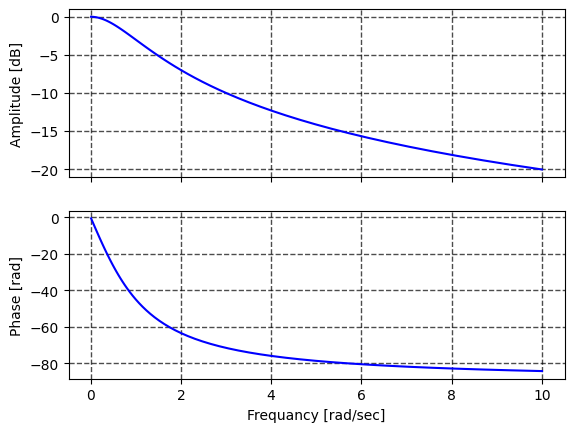

In [ ]:
from scipy import signal

num = [1]
den = [1, 1]

system = signal.TransferFunction(num, den)

w, mag, phase = signal.bode(system)

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(w, mag, color="blue")    # Bode magnitude plot
ax1.grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
ax1.grid(True)
ax1.set_ylabel("Amplitude [dB]")

ax2.plot(w, phase, color="blue")  # Bode phase plot
ax2.grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
ax2.grid(True)
ax2.set_ylabel("Phase [rad]")
ax2.set_xlabel("Frequancy [rad/sec]")
plt.show()

Проверим данный фильтр на примере сгенерированного сигнала с высокочастотным шумом

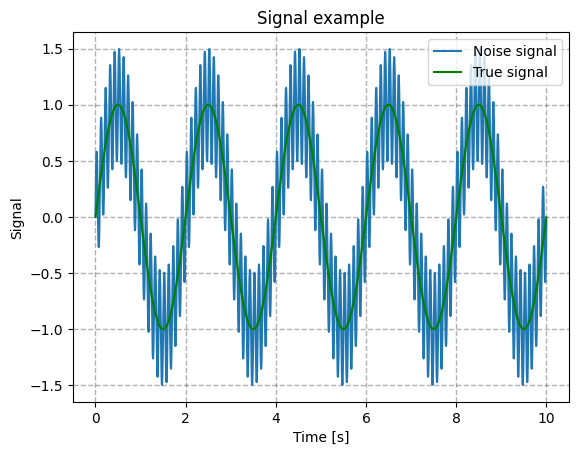

In [ ]:
import numpy as np

def generate_signal(T, t_max):
    t = np.arange(0, t_max, T)

    # полезный сигнал
    signal = np.sin(2 * np.pi * 0.5 * t)

    # высокочастотный шум
    noise = 0.5 * np.sin(2 * np.pi * 10 * t)

    # измерение
    y = signal + noise

    return t, signal, noise, y

T = 0.001
t_max = 10

t, signal, noise, y = generate_signal(T, t_max)

plt.plot(t, y, 'C0', label='Noise signal')
plt.plot(t, signal, 'g', label='True signal')
plt.legend()
plot_design("Signal example", "Time [s]", "Signal")

А теперь реализуем фильтр низких частот в коде

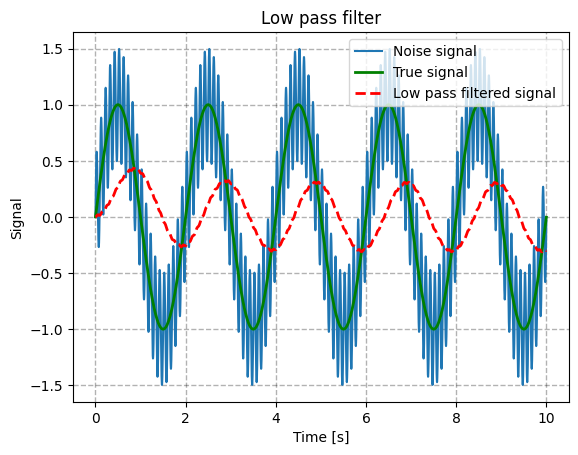

In [ ]:
def low_pass_filter(y, T):
    z = np.zeros_like(y)

    for k in range(1, len(y)):
        z[k] = z[k-1] + T * (-z[k-1] + y[k])

    return z

z_lp = low_pass_filter(y, T)

plt.plot(t, y, label='Noise signal')
plt.plot(t, signal, "g", label='True signal', linewidth=2)
plt.plot(t, z_lp, "r--", label='Low pass filtered signal', linewidth=2)
plt.legend()
plot_design("Low pass filter", "Time [s]", "Signal")

## **Фильтр высоких частот**

Интуитивно, если мы вычтем из сигнала все нижние частоты, то должны получить высокие частоты
$$
\text{high-pass} = \text{signal} - \text{low-pass}
$$


Учитывая что передаточная функция фильтра низких частот описывается как:
$$
W_{LP}(s) = \frac{1}{s+1}
$$

То фильтр высоких частот можно получить как следующую разницу
$$
W_{HP}(s) = 1 - \frac{1}{s+1}
$$

Что при упрощении дает передаточную функцию:

$$
W_{HP}(s) = \frac{s}{s+1}
$$

А соответственно частотная характеристика для высокочастотного фильтра будет выглядеть:

Частотная характеристика:

$$
|W(\omega)| = \frac{\omega}{\sqrt{\omega^2 + 1}}
$$

Свойства:
* Низкие частоты подавляются
* Высокие частоты проходят

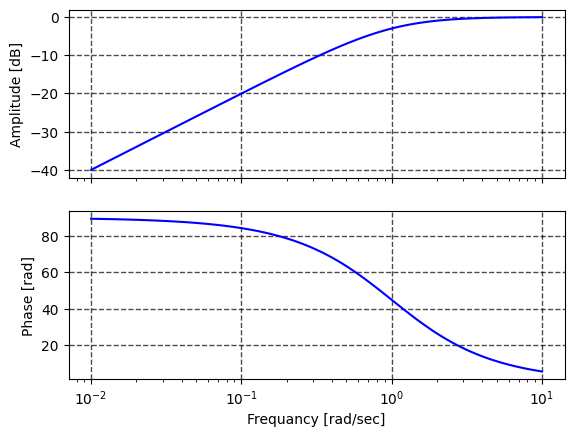

In [ ]:
from scipy import signal

num = [1, 0]
den = [1, 1]

system = signal.TransferFunction(num, den)

w, mag, phase = signal.bode(system)

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.semilogx(w, mag, color="blue")    # Bode magnitude plot
ax1.grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
ax1.grid(True)
ax1.set_ylabel("Amplitude [dB]")

ax2.semilogx(w, phase, color="blue")  # Bode phase plot
ax2.grid(color='black', linestyle='--', linewidth=1.0, alpha = 0.7)
ax2.grid(True)
ax2.set_ylabel("Phase [rad]")
ax2.set_xlabel("Frequancy [rad/sec]")
plt.show()

В целом, фильтр высоких частот можно записать как между оригинальным сигналом и результатом фильтрации нижних частот

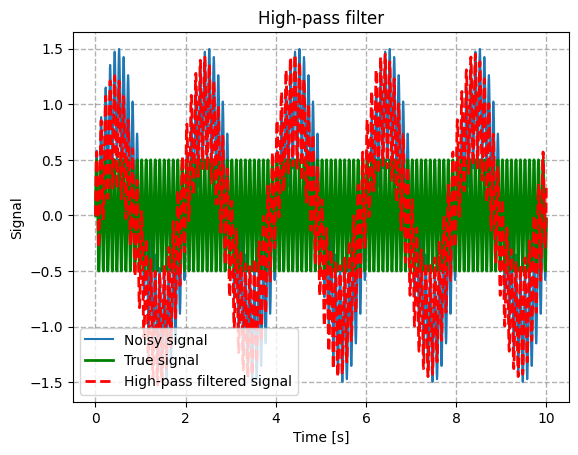

In [ ]:
def high_pass_filter(y, T):
    z_lp = low_pass_filter(y, T)
    z_hp = y - z_lp
    return z_hp

t, noise, signal, y = generate_signal(T, t_max)

z_hp = high_pass_filter(y, T)

plt.plot(t, y, label='Noisy signal')
plt.plot(t, signal, "g", label='True signal', linewidth=2)
plt.plot(t, z_hp, "r--", label='High-pass filtered signal', linewidth=2)
plt.legend()
plot_design("High-pass filter", "Time [s]", "Signal")

### **Упражнение: фильтрация зашумлённого сигнала**

> На данный момент что фильтр нижних и высоких частот не совсем подходит под наш пример. При фильтрации возникает большая просадка по амплитуде и задержка по фазе.
> Приведите функцию для фильтра нижних частот в более общий вид:
> $$
\dot{z} = -az + ay
$$
> где $a$ - коэффициент усиления фильтра
> подберите коэффициент $а$ так чтобы он лучше подходил для фильтрации нижних и верхних частот

ValueError: x, y, and format string must not be None

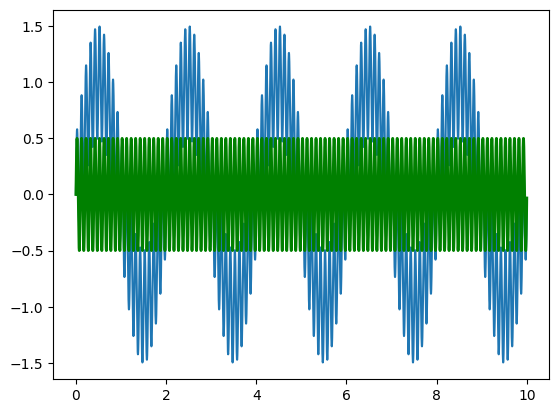

In [ ]:
def low_pass_filter_generalized(y, T, a):
    # Put your code here
    pass

def high_pass_filter_generalized(y, T, a):
    # Put your code here
    pass

t, signal, noise, y = generate_signal(T, t_max)

a = 1
z_lp = low_pass_filter_generalized(y, T, a)
plt.plot(t, y, label='Noise signal')
plt.plot(t, signal, "g", label='True signal', linewidth=2)
plt.plot(t, z_lp, "r--", label='Low-pass filtered signal', linewidth=2)
plt.legend()
plot_design("Low-pass filter", "Time [s]", "Signal")


z_hp = high_pass_filter(y, T)
plt.plot(t, y, label='Noisy signal')
plt.plot(t, noise, "g", label='True signal', linewidth=2)
plt.plot(t, z_hp, "r--", label='High-pass filtered signal', linewidth=2)
plt.legend()
plot_design("High-pass filter", "Time [s]", "Signal")

### **Упражнение: полосовой фильтр**
> Полосовой фильтр можно получить как разность двух фильтров нижних частот:
>$$
\text{band-pass} = \text{low-pass}_{high} - \text{low-pass}_{low}
$$
> Он пропускает частоты между двумя частотами среза.
> Реализуйте функцию фолосового фильтра и примените к примеру

In [ ]:
def generate_signal(T, t_max):
    t = np.arange(0, t_max, T)

    # низкочастотный шум
    noise_low = np.sin(2 * np.pi * 0.01 * t)

    # полезный сигнал
    signal = np.sin(2 * np.pi * 0.5 * t)

    # высокочастотный шум
    noise_high = 0.5 * np.sin(2 * np.pi * 10 * t)

    # измерение
    y = signal + noise_low + noise_high

    return t, signal, y

def band_pass(y, T, a_low, a_high):
    pass


t, signal, y = generate_signal(T, t_max)

a_low, a_high = 1, 1
z_lp = band_pass(y, T)
plt.plot(t, y, label='Noise signal')
plt.plot(t, signal, "g", label='True signal', linewidth=2)
plt.plot(t, z_lp, "r--", label='Band-pass filtered signal', linewidth=2)
plt.legend()
plot_design("Low pass filter", "Time [s]", "Signal")

# **PID-регулятор**

Одним из наиболее известных примеров динамических контроллеров является пропорционально-интегрально-дифференциальный регулятор (PID-регулятор).

В скалярном случае:

$$
u(t) = k_p e(t) + k_d \frac{d}{dt} e(t) + k_i \int_0^t e(\tau)\, d\tau
$$

где:
* $e(t)$ — ошибка регулирования
* $k_p$ — пропорциональный коэффициент
* $k_d$ — дифференциальный коэффициент
* $k_i$ — интегральный коэффициент



## **Идея PID-регулятора**

PID-регулятор формирует управление по трём составляющим:

* **P-часть** реагирует на текущую ошибку
* **I-часть** накапливает ошибку во времени и помогает устранять постоянную ошибку
* **D-часть** реагирует на скорость изменения ошибки и улучшает переходный процесс

Если обозначить желаемое положение через $r(t)$, а текущее положение через $x(t)$, то ошибка определяется как:

$$
e(t) = r(t) - x(t)
$$

## **Система mass-spring-damper**

Рассмотрим систему масса–пружина–демпфер:

$$
m\ddot{x} + b\dot{x} + kx = u
$$

где:
* $m$ — масса
* $b$ — коэффициент демпфирования
* $k$ — коэффициент жёсткости
* $u$ — управляющая сила

Введём переменные состояния:

$$
x_1 = x, \quad x_2 = \dot{x}
$$

Тогда система в пространстве состояний принимает вид:

$$
\dot{x}_1 = x_2
$$

$$
\dot{x}_2 = \frac{1}{m}(u - bx_2 - kx_1)
$$

## **PID-регулятор для управления положением**

Пусть нужно удерживать массу в заданной точке $r$.

Тогда ошибка:
$$
e = r - x_1
$$

Управление задаётся как:
$$
u = k_p e + k_d \dot{e} + k_i \int e\,dt
$$

Если заданная координата постоянна, то:
$$
\dot{e} = -\dot{x}_1 = -x_2
$$

Тогда можно использовать формулу:
$$
u = k_p(r - x_1) - k_d x_2 + k_i \int (r - x_1)\,dt
$$

In [ ]:
def mass_spring_damper_PID(T, t_max, x0=np.array([[0.0], [0.0]]), kp = 30.0, ki = 10.0, kd = 10.0):
    t = np.arange(0, t_max, T)
    n = len(t)

    # System parameters
    m = 1.0
    b = 2.0
    k = 10.0

    # Reference signal
    r = np.ones(n)

    # Disturbance
    d = 0.5

    # Storage
    x = np.zeros((n, 2))
    u_hist = np.zeros(n)
    e_hist = np.zeros(n)

    # Initial state
    x_k = x0.astype(float).copy()

    # Integral of error
    e_int = 0.0

    for i in range(n):
        position = x_k[0, 0]
        velocity = x_k[1, 0]

        # Error
        e = r[i] - position
        e_int += e * T
        e_dot = -velocity

        # PID control
        u = kp * e + ki * e_int + kd * e_dot

        # System dynamics
        x1_dot = velocity
        x2_dot = (u + d - b * velocity - k * position) / m

        # Euler integration
        x_k[0, 0] = x_k[0, 0] + T * x1_dot
        x_k[1, 0] = x_k[1, 0] + T * x2_dot

        x[i] = x_k.ravel()
        u_hist[i] = u
        e_hist[i] = e

    return t, r, x, u_hist, e_hist

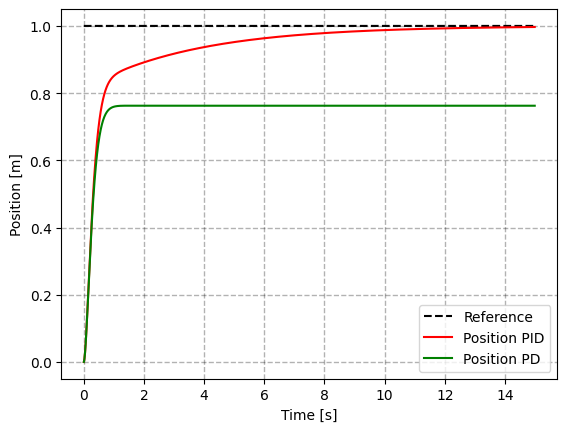

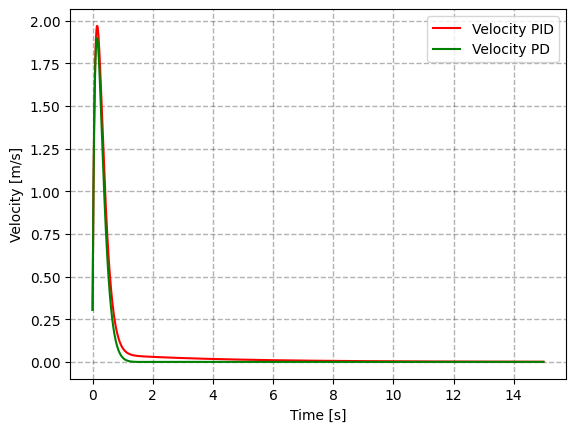

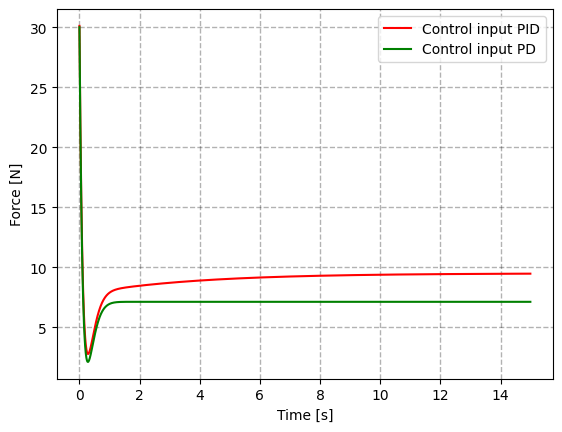

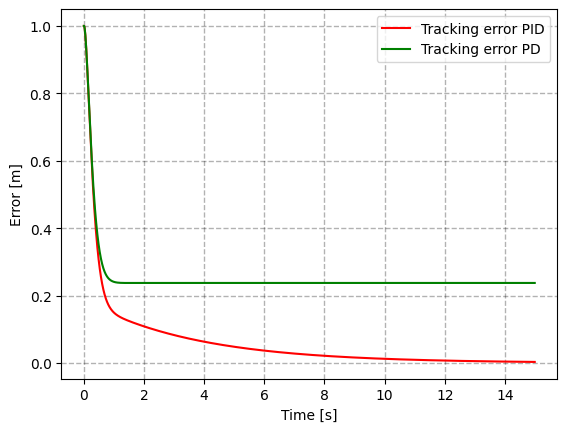

In [ ]:
T = 0.01
t_max = 15

t, r, x, u_hist, e_hist = mass_spring_damper_PID(T, t_max)
_, _, x_pd, u_hist_pd, e_hist_pd = mass_spring_damper_PID(T, t_max, ki=0)

plt.plot(t, r, 'k--', label='Reference')
plt.plot(t, x[:, 0], 'r', label='Position PID')
plt.plot(t, x_pd[:, 0], 'g', label='Position PD')
plt.legend()
plot_design(xlabel="Time [s]", ylabel="Position [m]")

plt.plot(t, x[:, 1], 'r', label='Velocity PID')
plt.plot(t, x_pd[:, 1], 'g', label='Velocity PD')
plt.legend()
plot_design(xlabel="Time [s]", ylabel="Velocity [m/s]")

plt.plot(t, u_hist, 'r', label='Control input PID')
plt.plot(t, u_hist_pd, 'g', label='Control input PD')
plt.legend()
plot_design(xlabel="Time [s]", ylabel="Force [N]")

plt.plot(t, e_hist, "r", label='Tracking error PID')
plt.plot(t, e_hist_pd, "g", label='Tracking error PD')
plt.legend()
plot_design(xlabel="Time [s]", ylabel="Error [m]")